# Part D·E 실행본
`shipbuilding_quant_case_1.ipynb`에서 **Part D·E와 그 선행 셀만** 실행한 사본입니다.
- 선행 셀: 설정, 주가 수집(Step 0), Part A 첫 셀(`corr_cols` 정의 — Part C 셀이 참조), Part C 첫 셀(`COST_*`, `metrics`)
- Part A 나머지, Part B(DART), Part C 전략 셀은 실행하지 않음

In [1]:
import os, time, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 110

DART_API_KEY = os.environ["DART_API_KEY"]    # 환경변수에서 읽음 (키 문자열을 노트북·출력에 남기지 않음)
assert DART_API_KEY.strip(), "환경변수 DART_API_KEY가 비어 있습니다"
START = "2015-01-01"
END   = pd.Timestamp.today().strftime("%Y-%m-%d")
RES_DIR = "results"                          # Part D·E 그래프·표 저장 폴더
os.makedirs(RES_DIR, exist_ok=True)

# 조선 유니버스  종목코드: (그래프용 영문 라벨, 그룹)
# 합병·상장폐지된 종목은 데이터가 있는 기간까지만 자동 사용됨
UNIVERSE = {
    "009540": ("HD KSOE(Hold)",  "HD"),
    "329180": ("HD HHI",         "HD"),
    "010620": ("HD Mipo",        "HD"),
    "010140": ("Samsung HI",     "SHI"),
    "042660": ("Hanwha Ocean",   "HANWHA"),
    "097230": ("HJ Shipbuilding","HJ"),
}
NAME  = {k: v[0] for k, v in UNIVERSE.items()}
GROUP = {k: v[1] for k, v in UNIVERSE.items()}

# 지주사는 자회사와 기계적으로 상관이 높아 동조화 계산에서 제외
CORR_EXCLUDE = ["009540"]
# HJ중공업은 건설부문 공급계약도 같은 이름으로 공시되므로 이벤트 스터디 기본값에서 제외
EVENT_TICKERS = ["009540", "329180", "010620", "010140", "042660"]

ROLL_WIN    = 60          # 동조화 롤링 윈도우(거래일)
EST_WIN     = (-250, -30) # 시장모형 추정구간
EVT_WIN     = (-10, 10)   # 이벤트 윈도우
MIN_EST_OBS = 120
REL = np.arange(EVT_WIN[0], EVT_WIN[1] + 1)

---
## Step 0. 주가 데이터
pykrx(수정주가)를 우선 쓰고, 실패하면 FinanceDataReader로 대체합니다.
거래정지일(거래량 0)과 일간 ±30% 초과 수익률(가격제한폭 밖 = 감자·데이터 오류)은 제거합니다.

In [2]:
def _load_one(ticker, start, end):
    s, e = start.replace("-", ""), end.replace("-", "")
    try:
        from pykrx import stock
        df = stock.get_market_ohlcv(s, e, ticker)          # adjusted=True 기본
        if df is not None and not df.empty:
            return df.rename(columns={"종가": "Close", "거래량": "Volume"})[["Close", "Volume"]]
    except Exception as ex:
        print(f"  pykrx 실패({ticker}): {ex}")
    try:
        import FinanceDataReader as fdr
        df = fdr.DataReader(ticker, start, end)
        if df is not None and not df.empty:
            print(f"  FDR 사용({ticker})")
            return df[["Close", "Volume"]]
    except Exception as ex:
        print(f"  FDR 실패({ticker}): {ex}")
    return None

def _load_kospi(start, end):
    try:
        from pykrx import stock
        df = stock.get_index_ohlcv(start.replace("-", ""), end.replace("-", ""), "1001")
        if df is not None and not df.empty:
            return df["종가"].rename("KOSPI")
    except Exception as ex:
        print(f"  pykrx 지수 실패: {ex}")
    import FinanceDataReader as fdr
    return fdr.DataReader("KS11", start, end)["Close"].rename("KOSPI")

def load_all(universe, start, end):
    close, vol = {}, {}
    for t in universe:
        print(f"loading {t} {NAME[t]}")
        df = _load_one(t, start, end)
        if df is None:
            print(f"  -> {t} 제외")
            continue
        close[t], vol[t] = df["Close"], df["Volume"]
        time.sleep(0.3)
    kospi = _load_kospi(start, end)
    kospi.index = pd.to_datetime(kospi.index)
    close = pd.DataFrame(close); close.index = pd.to_datetime(close.index)
    vol   = pd.DataFrame(vol);   vol.index   = pd.to_datetime(vol.index)
    return close.reindex(kospi.index), vol.reindex(kospi.index), kospi

def to_returns(close, vol, kospi, cap=0.30, tol=0.005):
    ret = close.pct_change(fill_method=None)
    ret = ret.mask((vol == 0) | vol.isna())
    # 정확히 ±30%인 상·하한가는 정상 관측치 → 부동소수점(1.3-1=0.30000000000000004)·수정주가 반올림 오차만큼 허용
    bad = ret.abs() > cap + tol
    if int(bad.values.sum()):
        print(f"|일간수익률| > {cap + tol:.1%} 관측치 {int(bad.values.sum())}개 NaN 처리")
    ret = ret.mask(bad)
    mkt = kospi.pct_change(fill_method=None)
    return ret, mkt

In [3]:
close, vol, kospi = load_all(UNIVERSE, START, END)
ret, mkt = to_returns(close, vol, kospi)
print("\n종목별 유효 수익률 관측치:")
print(ret.notna().sum().rename(NAME))

loading 009540 HD KSOE(Hold)
KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.


loading 329180 HD HHI


loading 010620 HD Mipo


loading 010140 Samsung HI


loading 042660 Hanwha Ocean


loading 097230 HJ Shipbuilding


Error occurred in get_index_ohlcv_by_date: Expecting value: line 1 column 1 (char 0)
Error occurred in __fetch: Expecting value: line 1 column 1 (char 0)
  pykrx 지수 실패: '지수명'



종목별 유효 수익률 관측치:
HD KSOE(Hold)      2849
HD HHI             1221
HD Mipo            2676
Samsung HI         2862
Hanwha Ocean       2559
HJ Shipbuilding    2814
dtype: int64


In [4]:
def rolling_avg_corr(x, window=60, min_assets=3, min_frac=0.8):
    vals = np.full(len(x), np.nan)
    for i in range(window - 1, len(x)):
        sub = x.iloc[i - window + 1:i + 1]
        sub = sub.loc[:, sub.notna().sum() >= int(window * min_frac)]
        if sub.shape[1] < min_assets:
            continue
        c = sub.corr().values
        iu = np.triu_indices(c.shape[0], 1)
        vals[i] = np.nanmean(c[iu])
    return pd.Series(vals, index=x.index)

corr_cols = [c for c in ret.columns if c not in CORR_EXCLUDE]
ex_ret  = ret[corr_cols].sub(mkt, axis=0)                  # 시장조정수익률
theme     = rolling_avg_corr(ex_ret,       ROLL_WIN).rename("theme (market-adj)")
theme_raw = rolling_avg_corr(ret[corr_cols], ROLL_WIN).rename("raw corr")

theme_rank = theme.expanding(min_periods=250).rank(pct=True)
def to_regime(r):
    return pd.cut(r, [0, 0.2, 0.8, 1.0], labels=["Low", "Mid", "High"], include_lowest=True)
regime = to_regime(theme_rank)

sector_ex = ex_ret.mean(axis=1, skipna=True)               # 동일가중 섹터 초과수익
print(theme.describe())
print("\n레짐 분포:\n", regime.value_counts())

count   2,816.0000
mean        0.4301
std         0.1126
min         0.0958
25%         0.3414
50%         0.4330
75%         0.5173
max         0.7562
Name: theme (market-adj), dtype: float64

레짐 분포:
 theme (market-adj)
Mid     1572
High     644
Low      351
Name: count, dtype: int64


In [5]:
COST_BUY  = 0.00015              # 매수 수수료
COST_SELL = 0.00015 + 0.0015     # 매도 수수료 + 거래세 (※ 최신 세율 확인 후 수정)
IS_END    = "2020-12-31"         # 여기까지 In-sample, 이후 Out-of-sample

sector_ret = ret[corr_cols].mean(axis=1, skipna=True).fillna(0)   # 동일가중 조선 섹터
bench      = mkt.fillna(0)

def backtest(weight, asset_ret, cost_buy=COST_BUY, cost_sell=COST_SELL):
    w = weight.shift(1).fillna(0).clip(0, 1)          # t 신호 → t+1 적용
    dw = w.diff().fillna(w)
    cost = dw.clip(lower=0) * cost_buy + (-dw).clip(lower=0) * cost_sell
    gross = w * asset_ret
    return pd.DataFrame({"w": w, "gross": gross, "net": gross - cost, "cost": cost})

def metrics(r, name="", rf=0.0):
    r = r.dropna()
    if len(r) < 60:
        return {}
    cum = (1 + r).prod()
    yrs = len(r) / 252
    cagr = cum ** (1 / yrs) - 1
    vol = r.std() * np.sqrt(252)
    eq = (1 + r).cumprod()
    mdd = (eq / eq.cummax() - 1).min()
    return {"strategy": name, "CAGR(%)": cagr * 100, "Vol(%)": vol * 100,
            "Sharpe": (cagr - rf) / vol if vol > 0 else np.nan, "MDD(%)": mdd * 100,
            "Calmar": cagr / abs(mdd) if mdd < 0 else np.nan,
            "Hit(%)": (r > 0).mean() * 100, "Days": len(r)}

---
# Part D. 페어트레이딩 — 섹터가 아니라 종목 간 상대가격
Part A·C에서 **섹터 방향 타이밍은 실패**했습니다. 그런데 조선주들이 같이 움직인다는 사실(A1)은
반대로 "같이 움직이는 두 종목의 상대가격이 벌어지면 되돌아오는가"라는 질문으로 쓸 수 있습니다.

- 헤지비율과 z-score는 **롤링 윈도우**로만 계산 (전체표본 회귀 = 룩어헤드)
- 진입 |z| ≥ 2, 청산 |z| ≤ 0.5, 신호는 t일 → t+1일 적용
- 비용: 양쪽 다리 모두 수수료·거래세 + 숏 다리 대차수수료(연율)
- **롱숏 버전**(이론)과 **롱온리 스위칭 버전**(개인 실행 가능)을 나란히 비교

In [6]:
from statsmodels.tsa.stattools import coint, adfuller

BORROW_ANNUAL = 0.03      # 공매도 대차수수료 연율 (기관 기준 가정)
LOOKBACK  = 120           # 헤지비율·z-score 롤링 윈도우
Z_ENTRY, Z_EXIT = 2.0, 0.5

logpx = np.log(close).replace([np.inf, -np.inf], np.nan)

def half_life(spread):
    s = spread.dropna()
    if len(s) < 60: return np.nan
    ds, lag = s.diff().dropna(), s.shift(1).dropna()
    idx = ds.index.intersection(lag.index)
    b = np.polyfit(lag[idx], ds[idx], 1)[0]
    return -np.log(2) / b if b < 0 else np.nan

def screen_pairs(logpx, min_obs=500):
    rows = []
    cols = list(logpx.columns)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            d = logpx[[a, b]].dropna()
            if len(d) < min_obs: continue
            try:
                p = coint(d[a], d[b])[1]
            except Exception:
                continue
            beta = np.polyfit(d[b], d[a], 1)[0]
            sp = d[a] - beta * d[b]
            rows.append({"A": NAME[a], "B": NAME[b], "a": a, "b": b, "obs": len(d),
                         "coint p": p, "ADF p": adfuller(sp)[1],
                         "half-life(d)": half_life(sp),
                         "corr(ret)": ret[[a, b]].dropna().corr().iloc[0, 1]})
    return pd.DataFrame(rows).sort_values("coint p")

pairs = screen_pairs(logpx)
display(pairs.drop(columns=["a", "b"]))
pairs.to_csv(f"{RES_DIR}/D0_coint_screen.csv", index=False, encoding="utf-8-sig")
print("coint p < 0.05 이면 두 종목의 장기 균형관계(공적분)를 기각하지 못함 = 페어 후보")

,A,B,obs,coint p,ADF p,half-life(d),corr(ret)
2,HD KSOE(Hold),Samsung HI,2875,0.0129,0.0028,94.3973,0.6719
3,HD KSOE(Hold),Hanwha Ocean,2875,0.0620,0.0173,141.7435,0.6290
12,Samsung HI,Hanwha Ocean,2875,0.0756,0.0220,99.3179,0.6232
7,HD HHI,Hanwha Ocean,1222,0.1457,0.0496,51.2681,0.6162
5,HD HHI,HD Mipo,1036,0.2065,0.0776,50.1335,0.7089
6,HD HHI,Samsung HI,1222,0.2245,0.0865,61.3295,0.6561
0,HD KSOE(Hold),HD HHI,1222,0.3122,0.1344,68.0808,0.7423
10,HD Mipo,Hanwha Ocean,2689,0.3577,0.2287,287.2222,0.5506
8,HD HHI,HJ Shipbuilding,1222,0.3965,0.1852,154.6805,0.4266
9,HD Mipo,Samsung HI,2689,0.6551,0.4073,410.8492,0.6125


coint p < 0.05 이면 두 종목의 장기 균형관계(공적분)를 기각하지 못함 = 페어 후보


■ 롱숏 (이론)


,CAGR(%),Vol(%),Sharpe,MDD(%),Calmar,Hit(%),Days,trades,round trips,time in mkt(%)
strategy,,,,,,,,,,
HD KSOE(Hold) / Samsung HI,1.5470,15.2623,0.1014,-45.7459,0.0338,22.7353,2837,38,19,45.6468
HD KSOE(Hold) / Hanwha Ocean,1.9176,14.0896,0.1361,-23.9764,0.0800,18.2493,2559,30,15,36.4596
Samsung HI / Hanwha Ocean,2.6531,18.1681,0.1460,-32.8349,0.0808,27.8367,2547,34,17,55.2807


■ 롱온리 스위칭 (개인 실행 가능)


,CAGR(%),Vol(%),Sharpe,MDD(%),Calmar,Hit(%),Days,trades,round trips,time in mkt(%)
strategy,,,,,,,,,,
HD KSOE(Hold) / Samsung HI,7.2034,27.4184,0.2627,-35.7342,0.2016,21.3253,2837,38,19,45.6468
HD KSOE(Hold) / Hanwha Ocean,3.7759,29.3259,0.1288,-61.1353,0.0618,16.8034,2559,30,15,36.4596
Samsung HI / Hanwha Ocean,10.3053,36.0815,0.2856,-63.0514,0.1634,25.4810,2547,34,17,55.2807


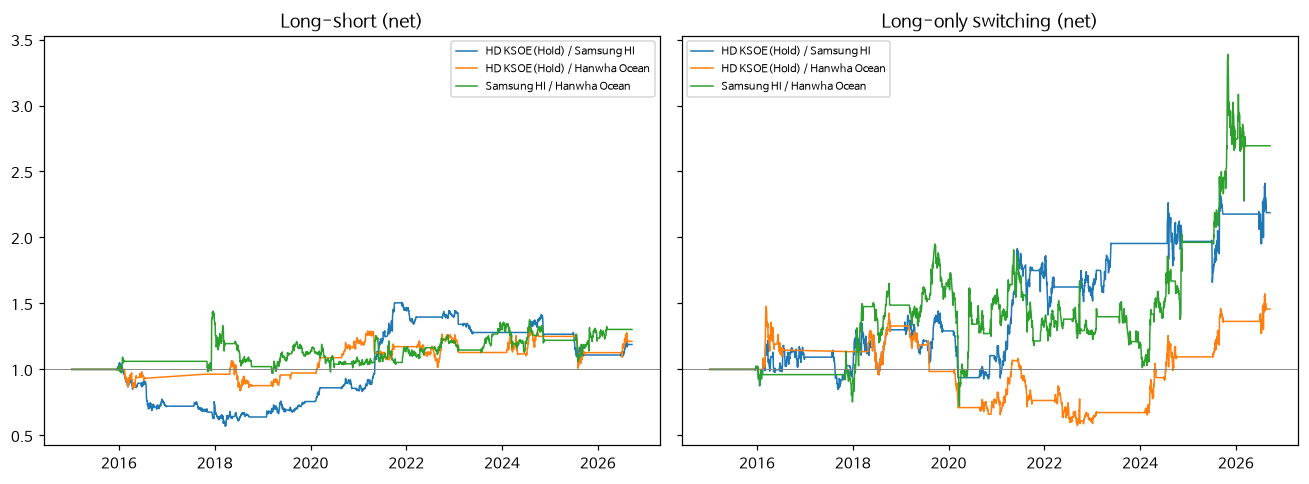

In [7]:
def pair_backtest(a, b, lookback=LOOKBACK, z_in=Z_ENTRY, z_out=Z_EXIT,
                  long_only=False, borrow=BORROW_ANNUAL,
                  cost_buy=COST_BUY, cost_sell=COST_SELL):
    d = pd.DataFrame({"la": logpx[a], "lb": logpx[b],
                      "ra": ret[a], "rb": ret[b]}).dropna()
    if len(d) < lookback + 100:
        return None
    # 롤링 헤지비율 (t까지의 정보만)
    cov = d["la"].rolling(lookback).cov(d["lb"])
    var = d["lb"].rolling(lookback).var()
    beta = (cov / var).clip(0.2, 5.0)
    spread = d["la"] - beta * d["lb"]
    z = (spread - spread.rolling(lookback).mean()) / spread.rolling(lookback).std()

    pos = np.zeros(len(d))                      # +1: A롱/B숏, -1: A숏/B롱
    for i in range(1, len(d)):
        p, zi = pos[i - 1], z.iloc[i]
        if np.isnan(zi):
            pos[i] = 0
        elif p == 0:
            pos[i] = 1 if zi <= -z_in else (-1 if zi >= z_in else 0)
        else:
            pos[i] = 0 if abs(zi) <= z_out else p
    pos = pd.Series(pos, index=d.index)
    p1, b1 = pos.shift(1).fillna(0), beta.shift(1).fillna(0)

    if long_only:                                # 싼 쪽만 매수 (숏 없음)
        gross = (p1 > 0) * d["ra"] + (p1 < 0) * d["rb"]
        wa, wb = (p1 > 0).astype(float), (p1 < 0).astype(float)
        borrow_cost = 0.0
    else:
        w = 1 / (1 + b1)
        gross = p1 * w * (d["ra"] - b1 * d["rb"])
        wa, wb = (p1 * w).abs(), (p1 * w * b1).abs()
        # 숏 다리 비중에만 대차수수료: p1>0이면 B 숏(wb), p1<0이면 A 숏(wa)
        short_w = wb.where(p1 > 0, 0.0) + wa.where(p1 < 0, 0.0)
        borrow_cost = short_w * borrow / 252
    trade = wa.diff().abs().fillna(wa) + wb.diff().abs().fillna(wb)
    cost = trade * (cost_buy + cost_sell) / 2 + borrow_cost
    out = pd.DataFrame({"z": z, "pos": pos, "gross": gross, "net": gross - cost})
    out.attrs["trades"] = int((pos.diff().abs() > 0).sum())               # 포지션 변경 횟수(진입+청산)
    out.attrs["round_trips"] = int(((pos != 0) & (pos.shift(1).fillna(0) == 0)).sum())   # 진입 횟수 = 왕복 거래 수
    return out

def pair_report(cands, long_only=False):
    rows, curves = [], {}
    for _, r in cands.iterrows():
        bt = pair_backtest(r["a"], r["b"], long_only=long_only)
        if bt is None: continue
        label = f"{r['A']} / {r['B']}"
        m = metrics(bt["net"], label)
        m["trades"] = bt.attrs["trades"]
        m["round trips"] = bt.attrs["round_trips"]
        m["time in mkt(%)"] = (bt["pos"] != 0).mean() * 100
        rows.append(m); curves[label] = bt["net"]
    return pd.DataFrame(rows).set_index("strategy"), curves

cands = pairs.head(3)
tab_ls, cur_ls = pair_report(cands, long_only=False)
tab_lo, cur_lo = pair_report(cands, long_only=True)
print("■ 롱숏 (이론)"); display(tab_ls)
print("■ 롱온리 스위칭 (개인 실행 가능)"); display(tab_lo)
pd.concat({"long-short": tab_ls, "long-only": tab_lo}).to_csv(f"{RES_DIR}/D1_pair_backtest.csv", encoding="utf-8-sig")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for k, v in cur_ls.items(): ax[0].plot(v.index, (1 + v).cumprod(), lw=1, label=k)
for k, v in cur_lo.items(): ax[1].plot(v.index, (1 + v).cumprod(), lw=1, label=k)
for a_, t_ in zip(ax, ["Long-short (net)", "Long-only switching (net)"]):
    a_.set_title(t_); a_.axhline(1, color="grey", lw=0.6); a_.legend(fontsize=7)
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_D1_pairs.png", bbox_inches="tight"); plt.show()

■ 민감도: HD KSOE(Hold) / Samsung HI


CAGR(%)  Sharpe   MDD(%)  trades  round trips
lookback z_entry                                               
60       1.5000   -5.3587 -0.3235 -55.7013      95           48
         2.0000   -4.5733 -0.3179 -50.6427      71           36
         2.5000   -2.3206 -0.2114 -31.6455      45           23
120      1.5000   -1.1149 -0.0647 -47.6604      46           23
         2.0000    1.5470  0.1014 -45.7459      38           19
         2.5000    1.4059  0.1059 -30.9988      28           14
250      1.5000   -7.1921 -0.5833 -62.1648      17            9
         2.0000   -6.5751 -0.5620 -60.1186      15            8
         2.5000   -4.7798 -0.4835 -49.1872       9            5

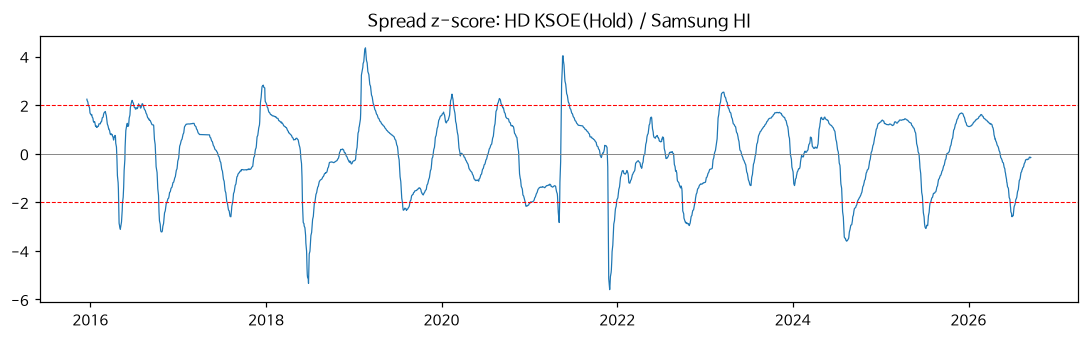

In [8]:
best = pairs.iloc[0]
grid = []
for lb in [60, 120, 250]:
    for zi in [1.5, 2.0, 2.5]:
        bt = pair_backtest(best["a"], best["b"], lookback=lb, z_in=zi)
        if bt is None: continue
        m = metrics(bt["net"])
        grid.append({"lookback": lb, "z_entry": zi, "CAGR(%)": m["CAGR(%)"],
                     "Sharpe": m["Sharpe"], "MDD(%)": m["MDD(%)"], "trades": bt.attrs["trades"],
                     "round trips": bt.attrs["round_trips"]})
print(f"■ 민감도: {best['A']} / {best['B']}")
tblD2 = pd.DataFrame(grid).set_index(["lookback", "z_entry"])
display(tblD2)
tblD2.to_csv(f"{RES_DIR}/D2_sensitivity.csv", encoding="utf-8-sig")
bt = pair_backtest(best["a"], best["b"])
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(bt.index, bt["z"], lw=0.8); ax.axhline(Z_ENTRY, color="r", ls="--", lw=0.7)
ax.axhline(-Z_ENTRY, color="r", ls="--", lw=0.7); ax.axhline(0, color="grey", lw=0.6)
ax.set_title(f"Spread z-score: {best['A']} / {best['B']}")
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_D2_zscore.png", bbox_inches="tight"); plt.show()

---
# Part E. 지주사 할인 — HD한국조선해양 vs HD현대중공업
조선 섹터에만 있는 구조입니다. 지주사는 상장 자회사 지분을 보유하므로 두 주가는 묶여 움직이고,
그 비율이 벌어졌다 좁혀지는지를 같은 z-score 엔진으로 검정합니다.

`STAKE`에 지분율을 넣으면 NAV 할인율로, 비워두면 단순 상대주가로 계산합니다.
HD현대중공업은 2021년 상장이라 표본이 짧다는 점을 결과 해석에 반드시 반영하세요.

공통 표본: 2021-09-17 ~ 2026-09-17 (1222일)
상대주가 로그스프레드 ADF p = 0.107  (0.05 미만이면 평균회귀 근거)
반감기 = 68.4일


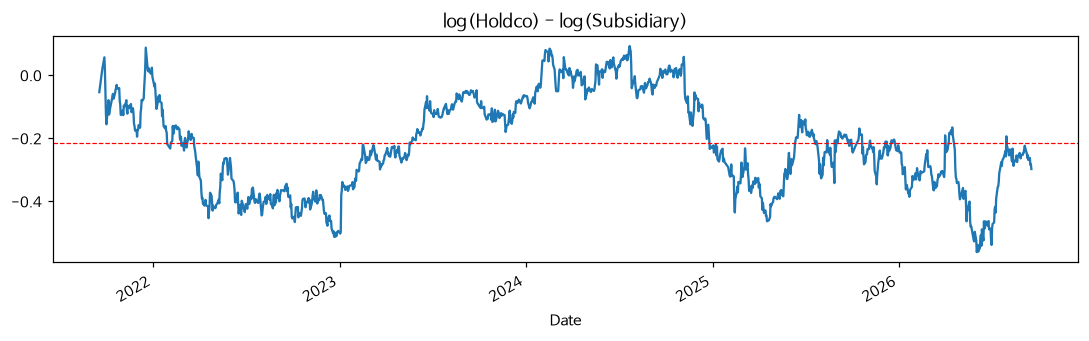

,CAGR(%),Vol(%),Sharpe,MDD(%),Calmar,Hit(%),Days,trades,round trips
strategy,,,,,,,,,
Holdco pair long-short,-6.4940,12.4794,-0.5204,-32.9992,-0.1968,20.4750,1221,12,6
Holdco pair long-only,18.7144,28.3376,0.6604,-26.7040,0.7008,19.4103,1221,12,6


주의: 표본이 짧고 거래 횟수가 적으면 Sharpe는 참고치로만 보세요


In [9]:
HOLDCO, SUBSID = "009540", "329180"
STAKE = None      # 예: 0.42 (지주사의 자회사 지분율). None이면 단순 상대주가 사용
SHARES = None     # (지주사 발행주식수, 자회사 발행주식수) 튜플. NAV 계산 시 필요

d = pd.DataFrame({"h": close[HOLDCO], "s": close[SUBSID]}).dropna()
print(f"공통 표본: {d.index.min().date()} ~ {d.index.max().date()} ({len(d)}일)")

if STAKE and SHARES:
    nav = close[SUBSID] * SHARES[1] * STAKE
    mcap = close[HOLDCO] * SHARES[0]
    disc = (1 - mcap / nav).dropna()
    disc.plot(figsize=(10, 3.2), title="Holdco NAV discount")
    plt.axhline(disc.mean(), color="r", ls="--", lw=0.8); plt.tight_layout(); plt.show()
    print(f"평균 할인율 {disc.mean():.1%}, 현재 {disc.iloc[-1]:.1%}, ADF p={adfuller(disc)[1]:.3f}")
else:
    sp = np.log(d["h"]) - np.log(d["s"])
    print(f"상대주가 로그스프레드 ADF p = {adfuller(sp)[1]:.3f}  (0.05 미만이면 평균회귀 근거)")
    print(f"반감기 = {half_life(sp):.1f}일")
    sp.plot(figsize=(10, 3.2), title="log(Holdco) - log(Subsidiary)")
    plt.axhline(sp.mean(), color="r", ls="--", lw=0.8)
    plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_E1_holdco.png", bbox_inches="tight"); plt.show()

bt_ls = pair_backtest(HOLDCO, SUBSID, long_only=False)
bt_lo = pair_backtest(HOLDCO, SUBSID, long_only=True)
rows = []
for lbl, bt in [("Holdco pair long-short", bt_ls), ("Holdco pair long-only", bt_lo)]:
    if bt is None:
        print(f"{lbl}: 표본 부족으로 실행 불가"); continue
    m = metrics(bt["net"], lbl); m["trades"] = bt.attrs["trades"]; m["round trips"] = bt.attrs["round_trips"]
    rows.append(m)
if rows:
    tblE1 = pd.DataFrame(rows).set_index("strategy")
    display(tblE1)
    tblE1.to_csv(f"{RES_DIR}/E1_holdco_backtest.csv", encoding="utf-8-sig")
print("주의: 표본이 짧고 거래 횟수가 적으면 Sharpe는 참고치로만 보세요")